In [163]:
import torch

# how to use RNNCell理解RNNCell的尺寸和用法
batch_size = 1  #批量大小
seq_len = 3
input_size = 4
hidden_size = 2
cell = torch.nn.RNNCell(input_size=input_size, hidden_size=hidden_size)
# (seq, batch, features)
dataset = torch.randn(seq_len, batch_size, input_size)  #3维张量
print(dataset)
hidden = torch.zeros(batch_size, hidden_size)
for idx, input in enumerate(dataset):
    print(input)
    print('=' * 20, idx, '=' * 20)
    print('Input size: ', input.shape)
    hidden = cell(input, hidden)
    print('outputs size: ', hidden.shape)
    print(hidden)

tensor([[[-0.2502,  0.5765, -0.3815, -0.1721]],

        [[ 0.6764, -0.3804, -0.0221,  0.6250]],

        [[ 0.7015,  1.8997,  0.7246,  2.1053]]])
tensor([[-0.2502,  0.5765, -0.3815, -0.1721]])
==================== 0 ====================
Input size:  torch.Size([1, 4])
outputs size:  torch.Size([1, 2])
tensor([[ 0.0465, -0.2540]], grad_fn=<TanhBackward0>)
tensor([[ 0.6764, -0.3804, -0.0221,  0.6250]])
==================== 1 ====================
Input size:  torch.Size([1, 4])
outputs size:  torch.Size([1, 2])
tensor([[ 0.5409, -0.6702]], grad_fn=<TanhBackward0>)
tensor([[0.7015, 1.8997, 0.7246, 2.1053]])
==================== 2 ====================
Input size:  torch.Size([1, 4])
outputs size:  torch.Size([1, 2])
tensor([[0.8478, 0.3405]], grad_fn=<TanhBackward0>)


In [164]:
import torch

input_size = 2
seq_len = 3
hidden_size = 6
batch_size = 5
cell = torch.nn.RNNCell(input_size=input_size, hidden_size=hidden_size)
datasets = torch.randn(seq_len, batch_size, input_size)
# print(dataset.shape)
# print(dataset)
hidden = torch.zeros(batch_size, hidden_size)
outputs = []
for idx, input in enumerate(datasets):
    # print(input.shape)
    # print(input)
    hidden = cell(input, hidden)
    print('=' * 20, idx, '=' * 20)
    print('Input size: ', input.shape)  #(batch_size,input_size)
    print('outputs size: ', hidden.shape)  #outputs的尺寸是(batch_size,hidden_size)
    print('hideen size: ', hidden.shape)  #hidden的尺寸是(batch_size,hidden_size)
    print(hidden)

==================== 0 ====================
Input size:  torch.Size([5, 2])
outputs size:  torch.Size([5, 6])
hideen size:  torch.Size([5, 6])
tensor([[-0.0957,  0.3731,  0.7761,  0.5174, -0.3502,  0.0665],
        [ 0.2726, -0.4306,  0.0176, -0.4881,  0.0570,  0.0301],
        [ 0.0146, -0.2762,  0.6760,  0.5039,  0.0901,  0.2062],
        [ 0.1744, -0.4481,  0.3364, -0.0428,  0.1401,  0.1321],
        [ 0.1188, -0.4551,  0.4867,  0.2204,  0.1826,  0.1860]],
       grad_fn=<TanhBackward0>)
==================== 1 ====================
Input size:  torch.Size([5, 2])
outputs size:  torch.Size([5, 6])
hideen size:  torch.Size([5, 6])
tensor([[ 0.4250, -0.7708,  0.1428,  0.4166, -0.1379, -0.0913],
        [ 0.1207, -0.2359,  0.2622, -0.1907,  0.4278,  0.2318],
        [ 0.1284, -0.6490,  0.5995,  0.6478, -0.1256,  0.2120],
        [ 0.1037,  0.1787,  0.3251, -0.2373, -0.3088,  0.0134],
        [ 0.0588, -0.2294,  0.5488,  0.3217, -0.2220,  0.1600]],
       grad_fn=<TanhBackward0>)
========

In [165]:
# how to use RNN:理解RNN的尺寸和用法
import torch

input_size = 2
seq_len = 3
hidden_size = 6
batch_size = 5
layer_num = 1
cell = torch.nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=layer_num)
datasets = torch.randn(seq_len, batch_size, input_size)
outputs, hidden = cell(datasets)
print(outputs.shape)  #outputs的尺寸是(seq_len,batch_size,hidden_size)这里的只包含最后一个时刻的输出
print(hidden.shape)  #hidden的尺寸是(layer_num,batch_size,hidden_size)#这里是最终时刻的隐藏状态

torch.Size([3, 5, 6])
torch.Size([1, 5, 6])


In [166]:
#用rnncell实现‘hello'--->'oholo'的预测
import torch
import torch.nn.functional as F

words = 'hello'
pre_words = 'lhlol'


def build_dict(words):
    unique_chars = list(dict.fromkeys(words))
    return {char: idx for idx, char in enumerate(unique_chars)}


def word2idx(words):
    return [word_dict[char] for char in words]


#建立字典
dict.fromkeys(words)  # 会自动去重并保留顺序：h, e, l, o
unique_chars = list(dict.fromkeys(words))
word_dict = build_dict(words)
idx_to_char = {idx: char for char, idx in word_dict.items()}
print(word_dict)
idx = word2idx(words)
pre_idx = word2idx(pre_words)
print(idx)
print(pre_idx)


def idx2char(idx):
    return word_dict[idx]


# 把idx转化为one-hot向量
idx_tensor = torch.tensor(idx)
print(idx_tensor.shape)
one_hot_tensor = F.one_hot(idx_tensor)
print(one_hot_tensor)
# 加载数据
input_size = len(unique_chars)
hidden_size = input_size
batch_size = 1
inputs = one_hot_tensor.float().view(-1, batch_size, input_size)
print(inputs.shape)
labels = torch.LongTensor(pre_idx).view(-1, batch_size)

{'h': 0, 'e': 1, 'l': 2, 'o': 3}
[0, 1, 2, 2, 3]
[2, 0, 2, 3, 2]
torch.Size([5])
tensor([[1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]])
torch.Size([5, 1, 4])


In [167]:
#定义模型
class Model(torch.nn.Module):
    def __init__(self, input_size, hidden_size, batch_size):
        super(Model, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.batch_size = batch_size
        self.cell = torch.nn.RNNCell(input_size=self.input_size, hidden_size=self.hidden_size)

    def forward(self, input, hidden):
        hideen = self.cell(input, hidden)
        return hideen

    def init_hidden(self):
        return torch.zeros(self.batch_size, self.hidden_size)


net = Model(input_size=input_size, hidden_size=hidden_size, batch_size=batch_size)

In [168]:
#定义优化器和损失函数
optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

In [169]:
#训练模型
loss_history = []  # 用于保存每个 epoch 的 loss
acc_history = []  # 用于保存每个 epoch 的准确率
for epoch in range(50):
    loss = 0
    correct_count = 0  # 记录这一轮猜对了好几个字
    total_count = 0  # 记录这一轮总共猜了几个字
    optimizer.zero_grad()
    hidden = net.init_hidden()
    print(f'Epoch {epoch + 1} Prediction: ', end='')
    for ins, label in zip(inputs, labels):
        hidden = net(ins, hidden)
        loss += criterion(hidden, label)
        _, idx = hidden.max(dim=1)  #这样取出来的idx是个tensor，需要用item()转化为int，这里的_是省略号，表示不用关心这个值
        print(idx_to_char[idx.item()], end='')
        # --- 统计准确率 ---
        if idx.item() == label.item():
            correct_count += 1
        total_count += 1

    loss.backward()
    optimizer.step()
    # 2. 记录数据
    loss_history.append(loss.item())
    acc = correct_count / total_count
    acc_history.append(acc)

    print(f', Loss:{loss.item():.4f}, Acc:{acc:.2%}')
    # print(',Epoch:{},Loss:{:.4f}'.format(epoch+1,loss.item()))

Epoch 1 Prediction: olloo, Loss:7.0263, Acc:40.00%
Epoch 2 Prediction: olloo, Loss:6.8693, Acc:40.00%
Epoch 3 Prediction: olloo, Loss:6.7160, Acc:40.00%
Epoch 4 Prediction: olloo, Loss:6.5660, Acc:40.00%
Epoch 5 Prediction: olloo, Loss:6.4200, Acc:40.00%
Epoch 6 Prediction: olloo, Loss:6.2790, Acc:40.00%
Epoch 7 Prediction: ollol, Loss:6.1440, Acc:60.00%
Epoch 8 Prediction: ollol, Loss:6.0160, Acc:60.00%
Epoch 9 Prediction: ollol, Loss:5.8955, Acc:60.00%
Epoch 10 Prediction: ollol, Loss:5.7832, Acc:60.00%
Epoch 11 Prediction: ollol, Loss:5.6790, Acc:60.00%
Epoch 12 Prediction: ollll, Loss:5.5827, Acc:40.00%
Epoch 13 Prediction: ollll, Loss:5.4939, Acc:40.00%
Epoch 14 Prediction: ollll, Loss:5.4116, Acc:40.00%
Epoch 15 Prediction: ollll, Loss:5.3352, Acc:40.00%
Epoch 16 Prediction: ollll, Loss:5.2637, Acc:40.00%
Epoch 17 Prediction: lllll, Loss:5.1965, Acc:60.00%
Epoch 18 Prediction: lllll, Loss:5.1328, Acc:60.00%
Epoch 19 Prediction: lllll, Loss:5.0720, Acc:60.00%
Epoch 20 Prediction: 

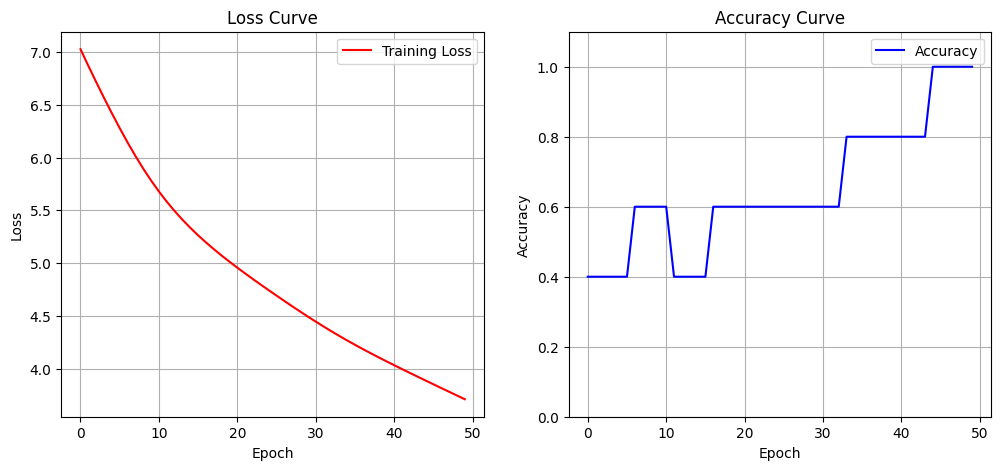

In [170]:
# 开始画图
# -------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))  # 设置画布大小

# 第一张图：画 Loss (损失率)
plt.subplot(1, 2, 1)  # 1行2列，第1张
plt.plot(loss_history, label='Training Loss', color='red')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)  # 显示网格
plt.legend()

# 第二张图：画 Accuracy (准确率)
plt.subplot(1, 2, 2)  # 1行2列，第2张
plt.plot(acc_history, label='Accuracy', color='blue')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)  # 强制Y轴范围在 0~1.1 之间，看得更清楚
plt.grid(True)
plt.legend()

plt.show()  # 显示图像

Epoch 50 | Loss: 0.7941
Epoch 100 | Loss: 0.6178
Epoch 150 | Loss: 0.5201
Epoch 200 | Loss: 0.3908
Epoch 250 | Loss: 0.3756
Epoch 300 | Loss: 0.3664


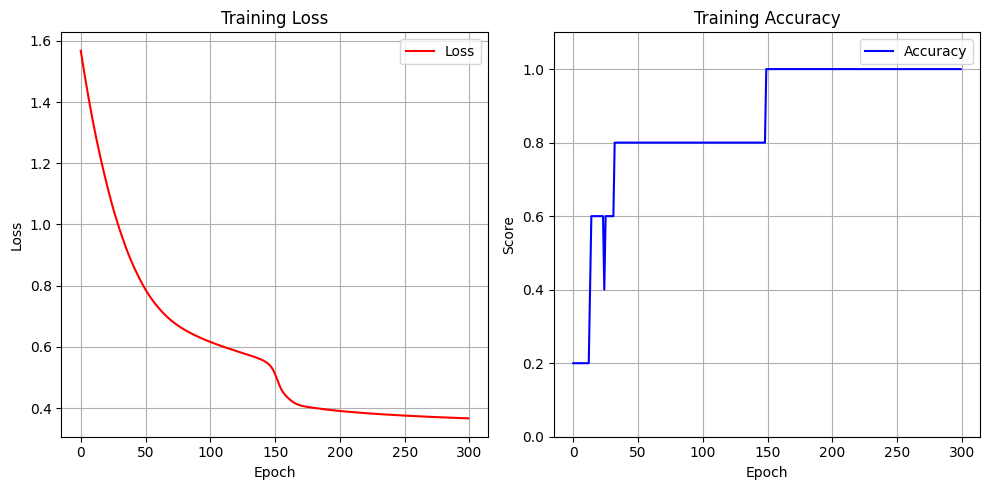

In [171]:
#利用RNN实现‘hello'--->'oholo'的预测
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt  # <--- 1. 引入绘图库

# --- 数据准备 ---
words = 'hello'
pre_words = 'oholo'

def build_dict(words):
    unique_chars = list(dict.fromkeys(words))
    return {char: idx for idx, char in enumerate(unique_chars)}

def word2idx(words):
    return [word_dict[char] for char in words]

unique_chars = list(dict.fromkeys(words))
word_dict = build_dict(words)
idx_to_char = {idx: char for char, idx in word_dict.items()}
idx = word2idx(words)
pre_idx = word2idx(pre_words)

# 转化为 Tensor
idx_tensor = torch.tensor(idx)
one_hot_tensor = F.one_hot(idx_tensor)

input_size = len(unique_chars)
hidden_size = input_size
batch_size = 1

inputs = one_hot_tensor.float().view(-1, batch_size, input_size)
labels = torch.LongTensor(pre_idx).view(-1, 1)

# --- 模型定义 ---
class Model(torch.nn.Module):
    def __init__(self, input_size, hidden_size, batch_size, num_layers=1):
        super(Model, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.batch_size = batch_size
        self.num_layers = num_layers
        self.rnn = torch.nn.RNN(input_size=self.input_size, hidden_size=self.hidden_size, num_layers=self.num_layers)
        
    def forward(self, input, hidden):
        output, hidden = self.rnn(input, hidden)
        return output, hidden

    def init_hidden(self):
        return torch.zeros(self.num_layers, self.batch_size, self.hidden_size)

net = Model(input_size=input_size, hidden_size=hidden_size, batch_size=batch_size)

# --- 训练设置 ---
optimizer = torch.optim.Adam(net.parameters(), lr=0.01) # 建议这里LR稍微改小一点，或者保持0.01观察
criterion = torch.nn.CrossEntropyLoss()

loss_history = [] 
acc_history = [] 

# --- 训练循环 ---
for epoch in range(300):
    optimizer.zero_grad()
    hidden = net.init_hidden()
    
    outputs, hidden = net(inputs, hidden)
    
    target = labels.view(-1)
    loss = criterion(outputs.view(-1, outputs.shape[-1]), target)

    loss.backward()
    optimizer.step()

    # 统计准确率
    with torch.no_grad():
        correct_count = 0
        total_count = 0
        _, predicted_indices = outputs.max(dim=2)
        predicted_indices = predicted_indices.view(-1)
        labels_flat = labels.view(-1)

        # 打印部分我注释掉了，避免刷屏，只保留最后一次
        if (epoch+1) % 50 == 0:
            print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

        for i in range(len(labels_flat)):
            if predicted_indices[i].item() == labels_flat[i].item():
                correct_count += 1
            total_count += 1

    loss_history.append(loss.item())
    acc = correct_count / total_count
    acc_history.append(acc)

# --- 2. 绘图代码 ---
# 创建一个图形框，包含2个子图
plt.figure(figsize=(10, 5))

# 第一张图：Loss
plt.subplot(1, 2, 1) # 1行2列，第1张
plt.plot(loss_history, label='Loss', color='red')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True) # 显示网格
plt.legend()

# 第二张图：Accuracy
plt.subplot(1, 2, 2) # 1行2列，第2张
plt.plot(acc_history, label='Accuracy', color='blue')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.ylim(0, 1.1) # 固定y轴范围在0-1.1之间
plt.grid(True)
plt.legend()

# 显示图片
plt.tight_layout() # 自动调整间距
plt.show()

In [172]:
#对比rnn和rnncell
import torch

batch_size = 1
input_size = 4
hidden_size = 4
seq_len = 3

# 模拟输入数据 (3个时刻, batch=1, 特征=4)
inputs = torch.randn(seq_len, batch_size, input_size) 
hidden = torch.zeros(batch_size, hidden_size) # 初始 hidden

# ==========================================
# 方式 1: 使用 nn.RNN (全自动)
# ==========================================
rnn = torch.nn.RNN(input_size, hidden_size, num_layers=1)

# 一行代码搞定，自动跑完 seq_len 那么多次
outputs, h_n = rnn(inputs, hidden.unsqueeze(0)) 
# 注意：nn.RNN 需要 hidden 有 layer 维度 (1, batch, hidden)

print("RNN Output:", outputs.shape) 
# 结果: (3, 1, 4) -> 包含了所有时刻的结果


# ==========================================
# 方式 2: 使用 RNNCell (手动档)
# ==========================================
cell = torch.nn.RNNCell(input_size, hidden_size)

outputs_list = []
h = hidden # (batch, hidden) 不需要 layer 维度

# 必须自己写循环！
for i in range(seq_len):
    # 每次只取一个时间步的数据 inputs[i]
    # inputs[i] 的 shape 是 (batch_size, input_size)
    h = cell(inputs[i], h) 
    outputs_list.append(h)

# 把列表拼回去，变成和上面一样的格式
outputs_manual = torch.stack(outputs_list)

print("Cell Output:", outputs_manual.shape)
# 结果: (3, 1, 4) -> 结果是一模一样的！

RNN Output: torch.Size([3, 1, 4])
Cell Output: torch.Size([3, 1, 4])


In [173]:
#练手一下，实现abcde-->bcdef的预测

#数据处理
import torch
import torch.nn.functional as F
source_txt = 'bcdefg'
words = source_txt[:-1]#左闭右开
# print(words)
pre_words = source_txt[1:]
# print(pre_words)  
all_chars = words+pre_words

def build_dict(words):
    unique_chars = list(dict.fromkeys(words))
    return {char: idx for idx, char in enumerate(unique_chars)}
word_dict = build_dict(all_chars)
# print(word_dict)
def word2idx(words):
    return [word_dict[char] for char in words]
idx2char = {idx:char for char, idx in word_dict.items()}#反向字典
# print(idx2char[2])



In [174]:
# 加载数据
input_size = len(word_dict)#字典大小6
hidden_size = input_size
batch_size = 1
layer_num = 1
idx = word2idx(words)
pre_idx = word2idx(pre_words)
idx_tensor = torch.tensor(idx)
one_hot_tensor = F.one_hot(idx_tensor,num_classes=input_size)
print(one_hot_tensor.shape)#5 6
print(one_hot_tensor)
inputs = one_hot_tensor.float().view(-1,batch_size,input_size)
# print(inputs.shape)#5 1 6   
labels = torch.LongTensor(pre_idx).view(-1,batch_size)#5 1 ,相当于答案
# print(labels.shape)#5 1

torch.Size([5, 6])
tensor([[1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0]])


In [175]:
outputs.shape[-1]#5

4

In [176]:
target = labels.view(-1)#还是把预测值变为一维
print(target.shape)#5

torch.Size([5])


In [177]:
#定义模型
class RNNPredictor(torch.nn.Module):
    def __init__(self,input_size,hidden_size,batch_size,layer_num):
        super(RNNPredictor,self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.batch_size = batch_size
        self.layer_num = layer_num
        self.rnn = torch.nn.RNN(input_size=self.input_size,hidden_size=self.hidden_size,num_layers=self.layer_num)
    def forward(self,input,hidden):
        output,hidden = self.rnn(input,hidden)
        return output,hidden
    def init_hidden(self):
        return torch.zeros(self.layer_num,self.batch_size,self.hidden_size) 
net = RNNPredictor(input_size=input_size,hidden_size=hidden_size,batch_size=batch_size,layer_num=layer_num)

In [178]:
#定义优化器和损失函数
optimizer = torch.optim.Adam(net.parameters(),lr=0.01)
criterion = torch.nn.CrossEntropyLoss()#采用交叉熵损失函数

In [179]:
#训练模型
"""
“清零 -> 初始化 -> 前向 -> 算Loss -> 反向 -> 更新”
"""
loss_history = []
acc_history = []
for epoch in range(100):
    correct_count = 0
    total_count = 0
    optimizer.zero_grad()#优化器梯度归零
    hidden = net.init_hidden()#初始化隐藏状态
    #准备输入数据
    outputs,hidden = net(inputs,hidden)#这里直接会调用net类中的forward函数
    target = labels.view(-1)#还是把预测值变为一维 5
    loss = criterion(outputs.view(-1,outputs.shape[-1]),target)#计算损失
    loss.backward()#反向传播
    optimizer.step()#优化器更新参数
    #  统计与打印 (这部分不计算梯度，用来观察结果) ---
    with torch.no_grad():
        # 取出概率最大的索引
        # outputs shape: (Seq, Batch, Hidden) -> (5, 1, 6)
        # print(outputs.shape)
        # print(outputs)
        _, predicted = outputs.max(dim=-1) 
        # print(predicted)
        # 拉平成一维，方便和 target 对比
        predicted = predicted.view(-1)
        target = target.view(-1)
        
        # 计算这一轮猜对了几个
        correct_count = (predicted == target).sum().item()
        total_count = target.size(0)
        
        # 计算准确率
        acc = correct_count / total_count
        
        # 记录历史数据
        loss_history.append(loss.item())
        acc_history.append(acc)

        # 打印进度 (每5轮打一次)
        if (epoch + 1) % 5 == 0:
            # 把预测的数字翻译回字符看看
            pred_str = ''.join([idx2char[i.item()] for i in predicted])
            print(f'Epoch {epoch+1:02d} | Loss: {loss.item():.4f} | Acc: {acc:.0%} | Pred: {pred_str}')

Epoch 05 | Loss: 1.7835 | Acc: 20% | Pred: gdgcc
Epoch 10 | Loss: 1.5986 | Acc: 40% | Pred: gdgff
Epoch 15 | Loss: 1.4584 | Acc: 40% | Pred: gdgff
Epoch 20 | Loss: 1.3371 | Acc: 60% | Pred: ddgfg
Epoch 25 | Loss: 1.2223 | Acc: 60% | Pred: ddgfg
Epoch 30 | Loss: 1.1150 | Acc: 80% | Pred: ddefg
Epoch 35 | Loss: 1.0219 | Acc: 100% | Pred: cdefg
Epoch 40 | Loss: 0.9455 | Acc: 100% | Pred: cdefg
Epoch 45 | Loss: 0.8825 | Acc: 100% | Pred: cdefg
Epoch 50 | Loss: 0.8276 | Acc: 100% | Pred: cdefg
Epoch 55 | Loss: 0.7790 | Acc: 100% | Pred: cdefg
Epoch 60 | Loss: 0.7362 | Acc: 100% | Pred: cdefg
Epoch 65 | Loss: 0.6998 | Acc: 100% | Pred: cdefg
Epoch 70 | Loss: 0.6698 | Acc: 100% | Pred: cdefg
Epoch 75 | Loss: 0.6454 | Acc: 100% | Pred: cdefg
Epoch 80 | Loss: 0.6259 | Acc: 100% | Pred: cdefg
Epoch 85 | Loss: 0.6104 | Acc: 100% | Pred: cdefg
Epoch 90 | Loss: 0.5980 | Acc: 100% | Pred: cdefg
Epoch 95 | Loss: 0.5881 | Acc: 100% | Pred: cdefg
Epoch 100 | Loss: 0.5802 | Acc: 100% | Pred: cdefg


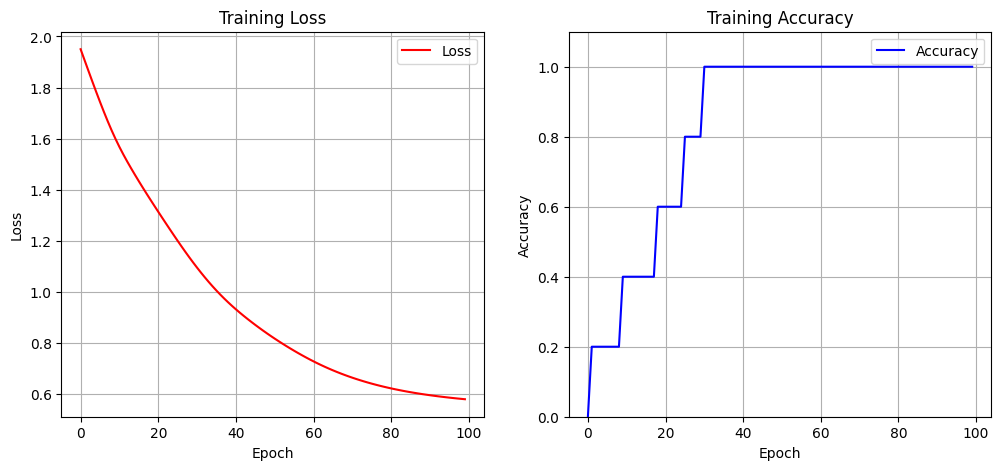

In [180]:
# --- 5. 画图代码 ---
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 画 Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(loss_history, label='Loss', color='red')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# 画 Accuracy 曲线
plt.subplot(1, 2, 2)
plt.plot(acc_history, label='Accuracy', color='blue')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1) # 强制Y轴范围，不然看不清
plt.grid(True)
plt.legend()

plt.show()